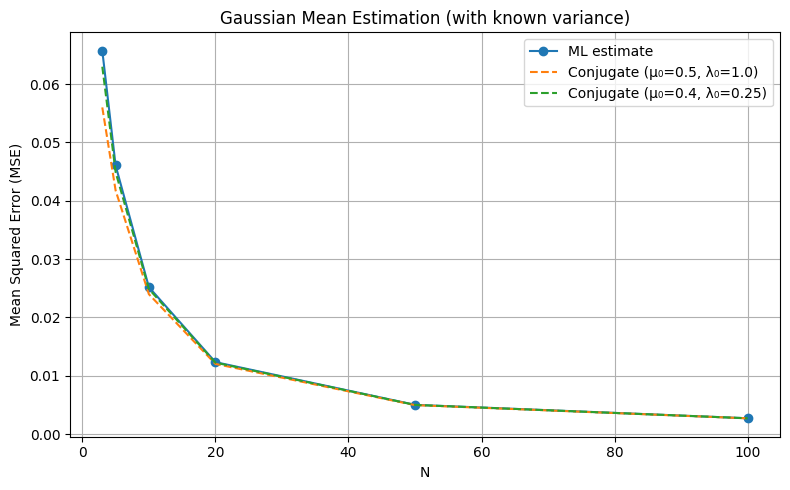

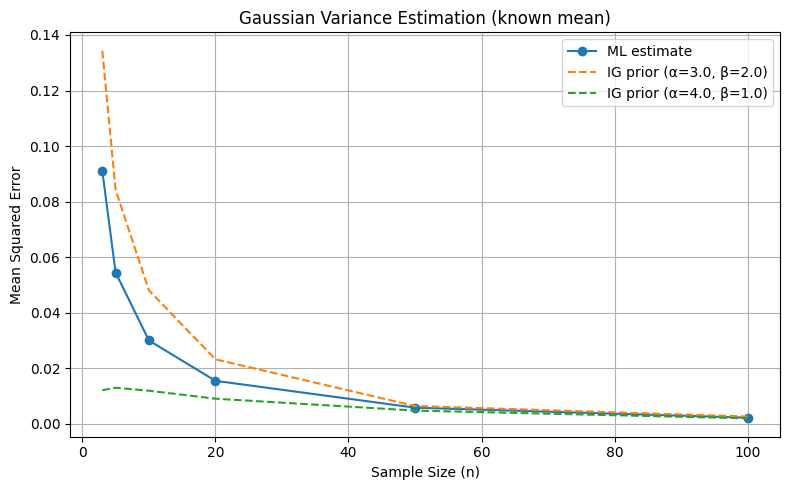

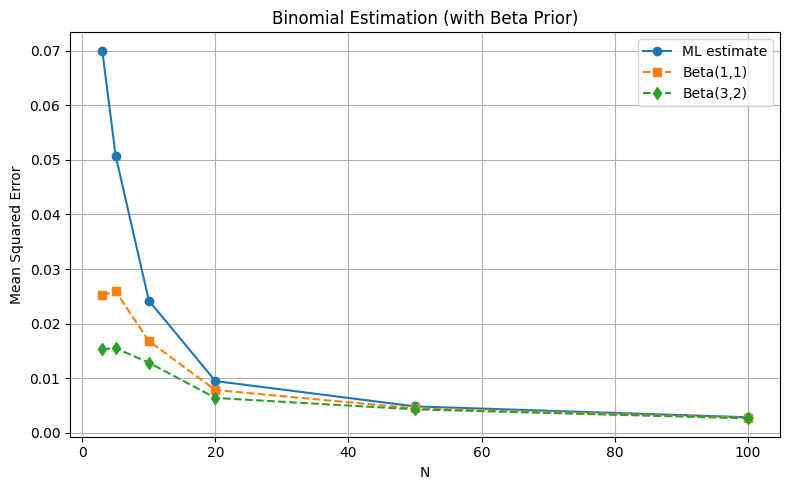

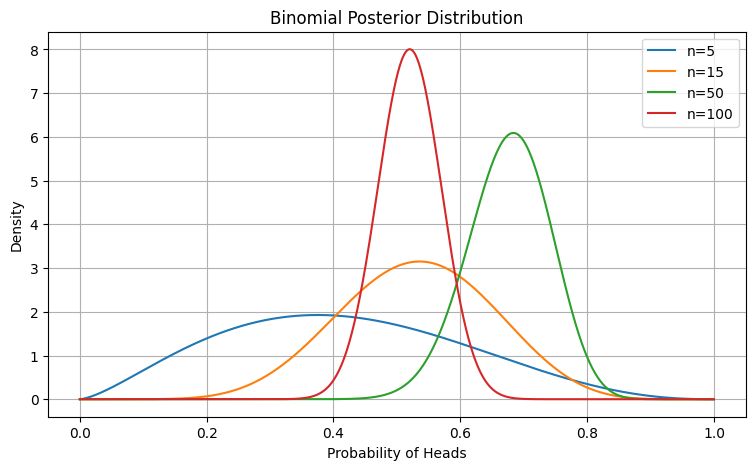

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm, gamma, invgamma
import random
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

np.random.seed(1234)

N= 100 # Number of trials
ns = [3, 5, 10, 20, 50, 100] # values of n to keep for plotting

# Gauss with known variance, trying to get estimate the mean
true_mean = 0.5
known_var = 0.25
hyperparams = [(0.5, 1.0), (0.4, 0.25)]  # (mu0, lambda0) pairs

ml_errs = [] # Instantiate an empty array
post_errs_all = [[] for _ in hyperparams] # a list of empty lists to store posterior errors

for n in ns:
    data = np.random.normal(true_mean, np.sqrt(known_var), size=(N, n))
    x_bar = data.mean(axis=1) # Mean of data along the row

    # err is MSE
    ml_err = ((x_bar - true_mean) ** 2).mean()
    ml_errs.append(ml_err)

    for i, (mu0, lambda0) in enumerate(hyperparams): # Posterior mean calculation
        lambda_n = lambda0 + n / known_var
        mu_n = (lambda0 * mu0 + (n / known_var) * x_bar) / lambda_n
        err = ((mu_n - true_mean) ** 2).mean()
        post_errs_all[i].append(err)

# Plot Mean Estimation Errors
plt.figure(figsize=(8, 5))
plt.plot(ns, ml_errs, 'o-', label='ML estimate')
for i, (mu0, lambda0) in enumerate(hyperparams):
    plt.plot(ns, post_errs_all[i], '--', label=f'Conjugate (μ₀={mu0}, λ₀={lambda0})')
plt.xlabel('N')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Gaussian Mean Estimation (with known variance)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gauss with known mean, trying to estimate the variance
mu_known = 0.5
true_var = 0.4
hyperparams = [(3.0, 2.0), (4.0, 1.0)]

ml_errs = []
post_errs_all = [[] for _ in hyperparams]

for n in ns:
    xs = np.random.normal(mu_known, np.sqrt(true_var), size=(N, n))
    s2 = ((xs - mu_known)**2).mean(axis=1)

    ml_err = ((s2 - true_var) ** 2).mean()
    ml_errs.append(ml_err)

    for i, (alpha0, beta0) in enumerate(hyperparams):
        alpha_post = alpha0 + n / 2
        beta_post = beta0 + 0.5 * ((xs - mu_known) ** 2).sum(axis=1)
        mean_post = beta_post / (alpha_post - 1)
        err = ((mean_post - true_var) ** 2).mean()
        post_errs_all[i].append(err)

# Plot Variance Estimation Errors
plt.figure(figsize=(8, 5))
plt.plot(ns, ml_errs, 'o-', label='ML estimate')
for i, (alpha0, beta0) in enumerate(hyperparams):
    plt.plot(ns, post_errs_all[i], '--', label=f'IG prior (α={alpha0}, β={beta0})')
plt.xlabel('Sample Size (n)')
plt.ylabel('Mean Squared Error')
plt.title('Gaussian Variance Estimation (known mean)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Binomial  with Beta prior
true_p = 0.5

ml_errs = []
post_errs_1 = []
post_errs_2 = []

for n in ns:
    flips = np.random.binomial(1, true_p, size=(N, n))
    heads = flips.sum(axis=1)
    ml = heads / n
    ml_err = ((ml - true_p) ** 2).mean()
    ml_errs.append(ml_err)

    # Prior 1: Beta where a and b are 1
    a, b = 1, 1
    post_mean_1 = (heads + a) / (n + a + b)
    err1 = ((post_mean_1 - true_p) ** 2).mean()
    post_errs_1.append(err1)

    # Prior 2:Beta where a and b are 3 and 2
    a, b = 3, 2
    post_mean_2 = (heads + a) / (n + a + b)
    err2 = ((post_mean_2 - true_p) ** 2).mean()
    post_errs_2.append(err2)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(ns, ml_errs, 'o-', label='ML estimate')
plt.plot(ns, post_errs_1, 's--', label='Beta(1,1)')
plt.plot(ns, post_errs_2, 'd--', label='Beta(3,2)')
plt.xlabel('N')
plt.ylabel('Mean Squared Error')
plt.title('Binomial Estimation (with Beta Prior)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# MOVIE TIME
# Binomial hyperparameters (Beta prior parameters)
binomial_hyperparams = [(0.5, 0.5), (0.7, 0.3), (0.3, 0.7), (5, 1)]
posterior_records = {hp: [] for hp in binomial_hyperparams}  # Store posteriors
N = 100  # Number of coin flips
data = [random.randint(0, 1) for i in range(N)]  # Generate binary data, 0 means tails, 1 means heads

# Compute posteriors for each prior
for a, b in binomial_hyperparams:
    m = 0  # heads count
    l = 0  # tails count
    for i in range(N):
        if data[i] == 1:
            m += 1
        else:
            l += 1
        if i in [4, 14, 49, 99]:  # Store at specific intervals
            posterior_records[(a, b)].append((i+1, a + m, b + l))

# Plot posteriors for first hyperparameter
a, b = binomial_hyperparams[0]
x = np.linspace(0, 1, 1000)
plt.figure(figsize=(9, 5))
for n, a_post, b_post in posterior_records[(a, b)]:
    y = beta.pdf(x, a_post, b_post)
    plt.plot(x, y, label=f'n={n}')
plt.title('Binomial Posterior Distribution')
plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Binomial animation
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 15)
ax.set_title('Binomial Posterior Animation')
ax.set_xlabel('Probability of Heads')
ax.set_ylabel('Density')

x = np.linspace(0, 1, 1000)
line, = ax.plot(x, beta.pdf(x, 0.5, 0.5), 'b-', lw=2)
num_trials = ax.text(0.02, 13.5, 'n=0', fontsize=12)

m_anim = 0  # heads count for animation
l_anim = 0  # tails count for animation

def update(frame):
    global m_anim, l_anim
    if data[frame] == 1:
        m_anim += 1
    else:
        l_anim += 1
    a_post = 0.5 + m_anim
    b_post = 0.5 + l_anim
    y = beta.pdf(x, a_post, b_post)
    line.set_ydata(y)
    num_trials.set_text(f'n={frame+1}')
    return line, num_trials

ani = FuncAnimation(fig, update, frames=N, interval=100, blit=True)
plt.close()

# Display animation
HTML(ani.to_jshtml())